In [5]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely import wkb
from src.data_format import format_output
from src.data import *


In [4]:
# filepath = PATH_TO_THE_FILE
filename = "filter_post_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_geo_v231225"

In [7]:
# Open the full csv file without geometries
rouge_df = pd.read_csv(filepath+'.csv')
rouge_df = format_output(rouge_df)

In [7]:
rouge_df.columns

Index(['appealCode', 'reportDate', 'reportLink', 'disasterType_IFRC',
       'impactSubtype', 'impactValue', 'impactValueMin', 'impactValueMax',
       'impactValuePrecision', 'impactUnit', 'startYear', 'startMonth',
       'startDay', 'endYear', 'endMonth', 'endDay', 'hazards', 'location',
       'locationPolygon', 'locationLowestAdmin', 'country_iso3',
       'sourceExcerpts', 'valid_errors_impactValue', 'valid_errors_loc',
       'valid_errors_dates', 'valid_errors_haz', 'flag_value_not_in_text',
       'flag_impactSubtype_reclass', 'flag_hazards_reclass',
       'flag_remove_number_unit', 'flag_SI_unit_standardization',
       'flag_non-SI_unit_standardization', 'flag_unit_processing_error',
       'flag_unit_nonstd', 'flag_reclass_subtype_from_unit', 'flag_pop_cntry',
       'flag_value_no_unit', 'flag_partial_unit', 'flag_geocoding_country',
       'flag_geocoding_osm', 'continent'],
      dtype='object')

In [8]:
#number of unique events
rouge_df.appealCode.nunique()

716

In [4]:
rouge_df.impactSubtype.value_counts()

impactSubtype
Water, Sanitation, and Hygiene                 1615
Agriculture and Access to Food                 1477
Residential Buildings                          1163
Affected People                                 940
Economy and Livelihood                          853
Healthcare                                      791
Transportation                                  769
Education                                       716
Human Health and Wellbeing                      706
Displaced People                                543
Human Deaths                                    426
Homeless People                                 371
Power and Energy Production                     355
Injured People                                  298
Infected and Ill People                         145
Missing People                                  132
Informal Settlements                             93
IT and Communication                             87
Undefined Infrastructure and Service Access      1

In [5]:
agriculture_africa = rouge_df[(rouge_df["continent"].apply(lambda x: "Africa" in x)) & (rouge_df["impactSubtype"]=="Agriculture and Access to Food")]
agriculture_africa.impactUnit.value_counts()

impactUnit
affected animals                         55
people                                   51
km**2 of crop production and forestry    34
km**2                                    31
%                                        22
kg of crop production and forestry       12
crop production and forestry              8
families                                  6
kg                                        5
EUR                                       3
agricultural structures                   3
% of victims                              2
of km**2                                  2
kg of food                                2
km²                                       1
kg of salt                                1
% of respondents                          1
kg of beans                               1
km**2 of crop farms                       1
km**2 of croplands                        1
% below the -year average                 1
% of -year average for -                  1
km**2 of agricultural

In [ ]:
# Open the full parquet file with geometries
filename_geo = "filter_post_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_v120226_geo"
rouge_gdf = gpd.read_parquet(DATA_OUT_PROC/(filename_geo+'.parquet'))

<Axes: >

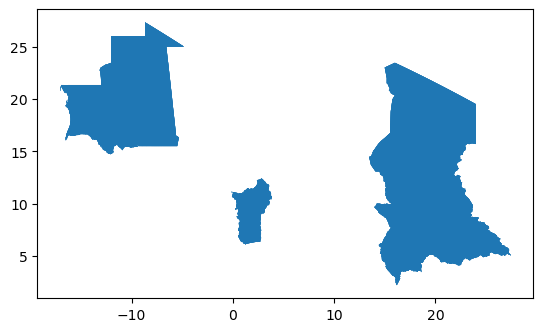

In [ ]:
rouge_gdf.head().plot()

In [90]:
continent_gdf = rouge_gdf[rouge_gdf["continent"].apply(lambda x: (len(x) == 0))]#.apply(lambda x: np.all([ct in ["Europe"] for ct in x]))]

In [75]:
country_gdf = rouge_gdf[rouge_gdf["country_iso3"].apply(lambda x: "FRA" in x)]

In [80]:
len([])

0

<Axes: >

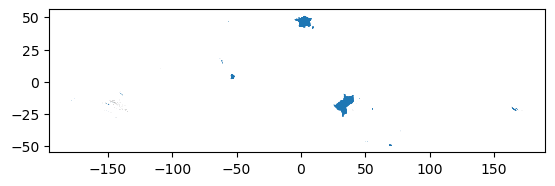

In [76]:
country_gdf.plot()

In [93]:
continent_gdf[["appealCode","country_iso3", "location", "continent", "locationPolygon","sourceExcerpts", "reportLink", 'flag_geocoding_country',
       'flag_geocoding_osm']]

,appealCode,country_iso3,location,continent,locationPolygon,sourceExcerpts,reportLink,flag_geocoding_country,flag_geocoding_osm
43,MDR49009,"[ATG, KNA]","[Antigua, Barbuda, Saint Kitts and Nevis]",[],"[Saint Philip, Saint John, Saint Mary, Saint P...","[Number of people affected: 2,300 people (1,80...",https://adore.ifrc.org/Download.aspx?FileId=29...,1.0,1.0
44,MDR49009,[ATG],"[Barbuda, Antigua]",[],"[Saint Philip, Saint John, Saint Mary, Saint P...",[The government of Antigua and Barbuda evacuat...,https://adore.ifrc.org/Download.aspx?FileId=29...,0.0,1.0
45,MDR49009,[ATG],"[Barbuda, Antigua]",[],"[Saint Philip, Saint John, Saint Mary, Saint P...",[The government of Antigua and Barbuda evacuat...,https://adore.ifrc.org/Download.aspx?FileId=29...,0.0,1.0
46,MDR49009,[ATG],[Barbuda],[],[Barbuda],[81% of Barbuda’s buildings were reported to h...,https://adore.ifrc.org/Download.aspx?FileId=29...,0.0,0.0
47,MDR49009,[ATG],[Barbuda],[],[Barbuda],"[On Barbuda, the hurricane destroyed or damage...",https://adore.ifrc.org/Download.aspx?FileId=29...,0.0,0.0
...,...,...,...,...,...,...,...,...,...
10690,MDRXK001,[],"[Vushtrri, Gjakova, Rahovec, Podujeva, Malisheva]",[],[],[Power stations and water supply stations were...,https://adore.ifrc.org/Download.aspx?FileId=15...,NaN,NaN
10691,MDRXK001,[],"[Vushtrri, Gjakova, Rahovec, Podujeva, Malisheva]",[],[],[Many families have been evacuated and some ar...,https://adore.ifrc.org/Download.aspx?FileId=15...,NaN,NaN
10692,MDRXK001,[],"[Vushtrri, Gjakova, Rahovec, Podujeva, Malisheva]",[],[],[Many families have been evacuated and some ar...,https://adore.ifrc.org/Download.aspx?FileId=15...,NaN,NaN
10693,MDRXK001,[],"[Vushtrri, Gjakova, Rahovec, Podujeva, Malisheva]",[],[],[the affected families have lost their home fu...,https://adore.ifrc.org/Download.aspx?FileId=15...,NaN,NaN


<Axes: >

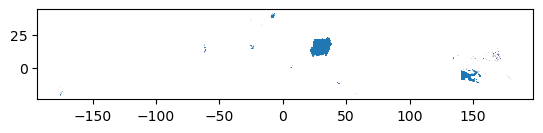

In [91]:
continent_gdf.plot()

In [67]:
wrong_geom = continent_gdf[(continent_gdf.geometry.bounds.minx<-45) & (continent_gdf.geometry.bounds.maxx > 100)]

In [68]:
wrong_geom[["appealCode", "location", "continent", "locationPolygon"]]

,appealCode,location,continent,locationPolygon
8652,MDRS1005,[],"[Africa, Europe]","[Malawi, Mozambique, Mayotte, France, Zimbabwe]"
8653,MDRS1005,[],"[Africa, Europe]","[Malawi, Mozambique, Mayotte, France, Zimbabwe]"
8665,MDRS1005,[],"[Africa, Europe]","[Mayotte, France]"
8666,MDRS1005,[],"[Africa, Europe]","[Mayotte, France]"
8667,MDRS1005,[],"[Africa, Europe]","[Mayotte, France]"
8670,MDRS1005,[],"[Africa, Europe]","[Mayotte, France]"
8672,MDRS1005,[],"[Africa, Europe]","[Mayotte, France]"


In [54]:
continent_gdf.geometry.bounds

,minx,miny,maxx,maxy
0,-17.068726,2.223043,27.458313,27.315880
1,-17.068726,2.223043,27.458313,27.315880
2,-17.068726,2.223043,27.458313,27.315880
3,-17.068726,2.223043,27.458313,27.315880
4,-17.068726,2.223043,27.458313,27.315880
...,...,...,...,...
11144,32.672543,-17.129533,35.918589,-9.367211
11145,34.250642,-17.129533,35.918560,-13.483106
11146,34.250642,-17.129533,35.918560,-13.483106
11147,34.250642,-17.129533,35.918560,-13.483106


In [16]:
rouge_gdf["continent"].value_counts()

continent
['Africa']                            3881
['Asia']                              3803
['South America']                     1084
['North America']                      966
['Europe']                             677
[]                                     491
['Oceania']                            235
['Africa', 'Europe']                     7
['Asia', 'South America']                4
['North America', 'South America']       1
Name: count, dtype: int64

In [7]:
rouge_gdf.columns

Index(['appealCode', 'reportDate', 'reportLink', 'disasterType_IFRC',
       'impactSubtype', 'impactValue', 'impactValueMin', 'impactValueMax',
       'impactValuePrecision', 'impactUnit', 'startYear', 'startMonth',
       'startDay', 'endYear', 'endMonth', 'endDay', 'hazards', 'location',
       'locationPolygon', 'locationLowestAdmin', 'country_iso3',
       'sourceExcerpts', 'valid_errors_impactValue', 'valid_errors_loc',
       'valid_errors_dates', 'valid_errors_haz', 'flag_impactSubtype_reclass',
       'flag_hazards_reclass', 'flag_remove_number_unit',
       'flag_SI_unit_standardization', 'flag_non-SI_unit_standardization',
       'flag_unit_processing_error', 'flag_unit_nonstd',
       'flag_reclass_subtype_from_unit', 'flag_pop_cntry',
       'flag_value_no_unit', 'flag_partial_unit', 'flag_geocoding_country',
       'flag_geocoding_osm', 'continent', 'geometry'],
      dtype='object')

In [8]:
rouge_gdf[rouge_gdf["appealCode"]=="MDRNG041"][["impactSubtype","impactValue","impactUnit","location", "geometry", "locationPolygon", "sourceExcerpts"]]

,impactSubtype,impactValue,impactUnit,location,geometry,locationPolygon,sourceExcerpts
7025,Affected People,3.000000e+06,people,"['Borno', 'Adamawa', 'Sokoto', 'Bauchi', 'Jiga...","MULTIPOLYGON (((10.27998 10.28014, 10.25741 10...","['Bauchi', 'Kogi', 'Bayelsa', 'Kebbi', 'Adamaw...",['The resulting devastation has caused extensi...
7026,Injured People,3.174000e+03,people,[],"MULTIPOLYGON (((4.26668 19.14556, 4.29423 19.1...","['Niger', 'Nigeria']",['The latest report by UNOCHA confirms that at...
7027,Human Deaths,3.110000e+02,people,[],"MULTIPOLYGON (((4.26668 19.14556, 4.29423 19.1...","['Niger', 'Nigeria']",['The latest report by UNOCHA confirms that at...
7028,Displaced People,3.900000e+05,people,"['29 states', 'Borno State', 'Maiduguri area']","MULTIPOLYGON (((12.24923 8.17242, 12.24892 8.1...","['Nigeria', 'Borno', 'Nganzai']","['A total of 390,000 people have been displace..."
7029,Homeless People,2.455000e+05,people,['29 states'],"MULTIPOLYGON (((12.24923 8.17242, 12.24892 8.1...",['Nigeria'],"['Roughly 245,500 people are living in collect..."
7030,Infected and Ill People,7.056000e+03,people,['36 states'],"MULTIPOLYGON (((12.24923 8.17242, 12.24892 8.1...",['Nigeria'],"['As 1 September 2024, Nigeria reported 7,056 ..."
7031,Agriculture and Access to Food,6.490307e+00,km**2,[],"MULTIPOLYGON (((4.26668 19.14556, 4.29423 19.1...","['Niger', 'Nigeria']","['Over 6,490,307 square metres (649.0307 hecta..."
7032,"Water, Sanitation, and Hygiene",NaN,null,"['29 states', 'Borno State', 'Maiduguri area']","MULTIPOLYGON (((12.24923 8.17242, 12.24892 8.1...","['Nigeria', 'Borno', 'Nganzai']","['Water points 3 contaminated, proper hygiene ..."
7033,Residential Buildings,NaN,null,"['Maiduguri', 'Borno State', 'Bauchi', 'Kebbi'...","MULTIPOLYGON (((10.27998 10.28014, 10.25741 10...","['Bauchi', 'Kogi', 'Bayelsa', 'Kebbi', 'Adamaw...",['The floods have washed away entire villages ...
7034,Economy and Livelihood,NaN,null,[],"MULTIPOLYGON (((4.26668 19.14556, 4.29423 19.1...","['Niger', 'Nigeria']","['The loss of trade, food production, and live..."
